In [1]:
import requests
import pandas as pd

SYMBOL = 'BTCUSDT'
INTERVAL = '1m'   # Intervalle d'une minute
LIMIT = 600        # Nombre de lignes à récupérer

def data_collection_api():
    response = requests.get(
        url='https://api.binance.com/api/v3/klines',
        params={
            "symbol": SYMBOL,
            "interval": INTERVAL,
            "limit": LIMIT
        }
    )
    
    if response.status_code != 200:
        print(f"Erreur {response.status_code}")
        return None
    
    data = response.json()
    
    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_volume", "taker_buy_quote_volume", "ignore"
    ]
    
    # Créer un DataFrame pandas
    df = pd.DataFrame(data, columns=columns)
    
    numeric_cols = ["open", "high", "low", "close", "volume",
                    "quote_asset_volume", "taker_buy_base_volume", "taker_buy_quote_volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)
    
    # Convertir timestamps en microsecondes pour Spark
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms").astype('datetime64[us]')
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms").astype('datetime64[us]')
    
    return df

df = data_collection_api()

# Sauvegarder en Parquet avec fastparquet
df.to_parquet("btc_data_bronze.parquet", engine="fastparquet", index=False)

print("Fichier Parquet sauvegardé ✅")


Fichier Parquet sauvegardé ✅


In [2]:
import os
# os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/amazon-corretto-11.jdk/Contents/Home"

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Bitcoin_Data") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()





In [3]:
df = spark.read.parquet("btc_data_bronze.parquet")
df.show(5)

+-------------------+--------+--------+--------+--------+---------+--------------------+------------------+----------------+---------------------+----------------------+------+
|          open_time|    open|    high|     low|   close|   volume|          close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|
+-------------------+--------+--------+--------+--------+---------+--------------------+------------------+----------------+---------------------+----------------------+------+
|2026-01-20 23:02:00|88254.54|88362.22|88249.72|88296.01| 30.13687|2026-01-20 23:02:...|   2661365.7460752|            7653|             11.27792|        995855.1277461|     0|
|2026-01-20 23:03:00|88296.02|88296.02|88097.15|88097.16| 69.05007|2026-01-20 23:03:...|   6088295.0226226|           10479|             13.79466|       1216135.4714683|     0|
|2026-01-20 23:04:00|88097.16| 88181.9|88097.16|88155.01|102.83992|2026-01-20 23:04:...|   9065752.9473191|        

In [4]:
df.count()

600

In [5]:
df.printSchema()

root
 |-- open_time: timestamp_ntz (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: double (nullable = true)
 |-- close_time: timestamp_ntz (nullable = true)
 |-- quote_asset_volume: double (nullable = true)
 |-- number_of_trades: long (nullable = true)
 |-- taker_buy_base_volume: double (nullable = true)
 |-- taker_buy_quote_volume: double (nullable = true)
 |-- ignore: string (nullable = true)



In [6]:
df.describe().show()

+-------+-----------------+-----------------+------------------+-----------------+------------------+------------------+------------------+---------------------+----------------------+------+
|summary|             open|             high|               low|            close|            volume|quote_asset_volume|  number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|
+-------+-----------------+-----------------+------------------+-----------------+------------------+------------------+------------------+---------------------+----------------------+------+
|  count|              600|              600|               600|              600|               600|               600|               600|                  600|                   600|   600|
|   mean|89204.62241666659|89227.52161666664| 89183.50911666661|89206.17821666673|11.717587516666661|1043413.7450223851|2558.7466666666664|    6.313810250000003|     562349.8853544712|   0.0|
| stddev|456.6451562188693| 448.32309318

column "volume" contient une valeur max plus grande que min ce qui siginfie que nous pouvons avoir des outliers 114 BTC > 0.34 BTC (outliers)
column "quote_asset_volume" une valeur max plus grande que min ce qui siginfie que nous pouvons avoir des outliers (ouliers)
column "number_of_trades" une differenciation entre les valeurs min et max le marché de trads a des ups and downs selon le volume (correlation)
column "taker_buy_quote_volume" une forte demande d achat (outliers)
column "ignore" valeurs est 0 on pourra le supprimé dans la phase de preporcessing 


In [7]:
# Vérifier l'état de la session Spark
print(df.sparkSession)

In [8]:
from pyspark.sql.functions import col

cols_outliers = [
    "volume","quote_asset_volume", "number_of_trades", 
    "taker_buy_base_volume", "taker_buy_quote_volume"
]


def detect_outliers_iqr(df,column):
    #on calcule q1 et q3
    q1= df.approxQuantile(column,[0.25],0.01)[0]
    q3 = df.approxQuantile(column,[0.75],0.01)[0]

    iqr= q3 - q1

    lower = q1 -1.5 * iqr
    upper = q3 + 1.5 * iqr

    #om calcule les outliers
    outlier_count = df.filter(
        (col(column) < lower) | (col(column) > upper)
    ).count()

    return{
        "column": column,
        "Q1" : q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outliers_Count": outlier_count
    }

results = []

for c in cols_outliers:
    res = detect_outliers_iqr(df, c)
    results.append(res)

results



[{'column': 'volume',
  'Q1': 3.65316,
  'Q3': 13.18377,
  'IQR': 9.530610000000001,
  'Lower_Bound': -10.642755000000001,
  'Upper_Bound': 27.479685000000003,
  'Outliers_Count': 40},
 {'column': 'quote_asset_volume',
  'Q1': 326107.7653469,
  'Q3': 1174311.1030775,
  'IQR': 848203.3377305999,
  'Lower_Bound': -946197.2412489998,
  'Upper_Bound': 2446616.1096733995,
  'Outliers_Count': 40},
 {'column': 'number_of_trades',
  'Q1': 1234.0,
  'Q3': 3241.0,
  'IQR': 2007.0,
  'Lower_Bound': -1776.5,
  'Upper_Bound': 6251.5,
  'Outliers_Count': 33},
 {'column': 'taker_buy_base_volume',
  'Q1': 1.48711,
  'Q3': 7.24797,
  'IQR': 5.760859999999999,
  'Lower_Bound': -7.154179999999998,
  'Upper_Bound': 15.889259999999997,
  'Outliers_Count': 36},
 {'column': 'taker_buy_quote_volume',
  'Q1': 132696.8990911,
  'Q3': 644918.4797164,
  'IQR': 512221.58062530006,
  'Lower_Bound': -635635.4718468501,
  'Upper_Bound': 1413250.8506543501,
  'Outliers_Count': 36}]

les outliers que nous avons remarqué est normaux puisqu'ils ont moins de 10% donc on va appliquer Capping ou Log transform

In [9]:
#verifier les valeurs nulls

from pyspark.sql.functions import  col, sum as Fsum


df.select([Fsum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+
|open_time|open|high|low|close|volume|close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+
|        0|   0|   0|  0|    0|     0|         0|                 0|               0|                    0|                     0|     0|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+



In [10]:
print("duplicates cols :", df.count() - df.dropDuplicates().count())

duplicates cols : 0


### prédire le prix de cloture du Bitcoin à T+10 minutes


In [11]:
from pyspark.sql.window import Window
from pyspark.sql import functions as F
from pyspark.sql.functions import col, avg

# Créer une fenêtre ordonnée par temps
window = Window.orderBy("open_time")

# Décaler la colonne 'close' de 10 lignes (10 minutes)
df = df.withColumn("close_t_plus_10", F.lead("close", 10).over(window))

 
#calcule de la Variations de prix (returns) 
window_lag =Window.orderBy("open_time")
df = df.withColumn(
    "returns_col", 
    (F.col("close")-F.lag("close",1).over(window_lag)) / F.lag("close",1).over(window_lag)
    )

#calcule de Moyennes mobiles (5, 10 minutes)
window_avg= Window.orderBy("open_time")
window_5 =window_avg.rowsBetween(-4 , 0)
window_10 = window_avg.rowsBetween(-9,0)

df = df.withColumn("ma_05",avg(col("close")).over(window_5))
df = df.withColumn("ma_10",avg(col("close")).over(window_10)) 


#calculer le taker ratio
df= df.withColumn(
    "taker_ratio",
    F.col("taker_buy_base_volume")/F.col("volume")
)




In [12]:
from pyspark.sql.functions import  col, sum as Fsum


df.select([Fsum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

26/01/21 10:05:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:05:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:05:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:05:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+-----------+-----+-----+-----------+
|open_time|open|high|low|close|volume|close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|close_t_plus_10|returns_col|ma_05|ma_10|taker_ratio|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+-----------+-----+-----+-----------+
|        0|   0|   0|  0|    0|     0|         0|                 0|               0|                    0|                     0|     0|             10|          1|    0|    0|          0|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+-----------+-----+-----+-----------+



In [13]:
df = df.dropna(subset=["close_t_plus_10","returns_col"])

In [14]:
df.select([Fsum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

26/01/21 10:05:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:05:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:05:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:05:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+-----------+-----+-----+-----------+
|open_time|open|high|low|close|volume|close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|close_t_plus_10|returns_col|ma_05|ma_10|taker_ratio|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+-----------+-----+-----+-----------+
|        0|   0|   0|  0|    0|     0|         0|                 0|               0|                    0|                     0|     0|              0|          0|    0|    0|          0|
+---------+----+----+---+-----+------+----------+------------------+----------------+---------------------+----------------------+------+---------------+-----------+-----+-----+-----------+



In [15]:


# matrice de correlation

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import numpy as np
import pandas as pd

cols_numeric = [
    "close", "volume", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_volume", "taker_buy_quote_volume",
    "returns_col", "ma_05", "ma_10", "taker_ratio", "close_t_plus_10"
]

assembler = VectorAssembler(
    inputCols=cols_numeric,
    outputCol="features"
)
df_vector = assembler.transform(df).select("features")


corr_matrix = Correlation.corr(df_vector, "features").head()[0]


corr_array = corr_matrix.toArray()


corr_df = pd.DataFrame(corr_array, columns=cols_numeric, index=cols_numeric)





26/01/21 10:06:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:06:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:06:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:06:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/21 10:06:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [45]:
corr_df.head()

,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,returns_col,ma_05,ma_10,taker_ratio,close_t_plus_10
close,1.000000,0.021056,0.022178,0.010998,0.093273,0.093954,0.154761,0.948188,0.888910,0.095066,0.671144
volume,0.021056,1.000000,0.999999,0.437041,0.872042,0.872030,0.016514,0.021214,0.031349,0.066919,0.067993
quote_asset_volume,0.022178,0.999999,1.000000,0.436966,0.872225,0.872214,0.016696,0.022249,0.032270,0.067088,0.068765
number_of_trades,0.010998,0.437041,0.436966,1.000000,0.210760,0.210789,-0.126176,0.064032,0.089375,-0.106104,0.046424
taker_buy_base_volume,0.093273,0.872042,0.872225,0.210760,1.000000,0.999999,0.235123,0.032908,0.026172,0.346090,0.129601


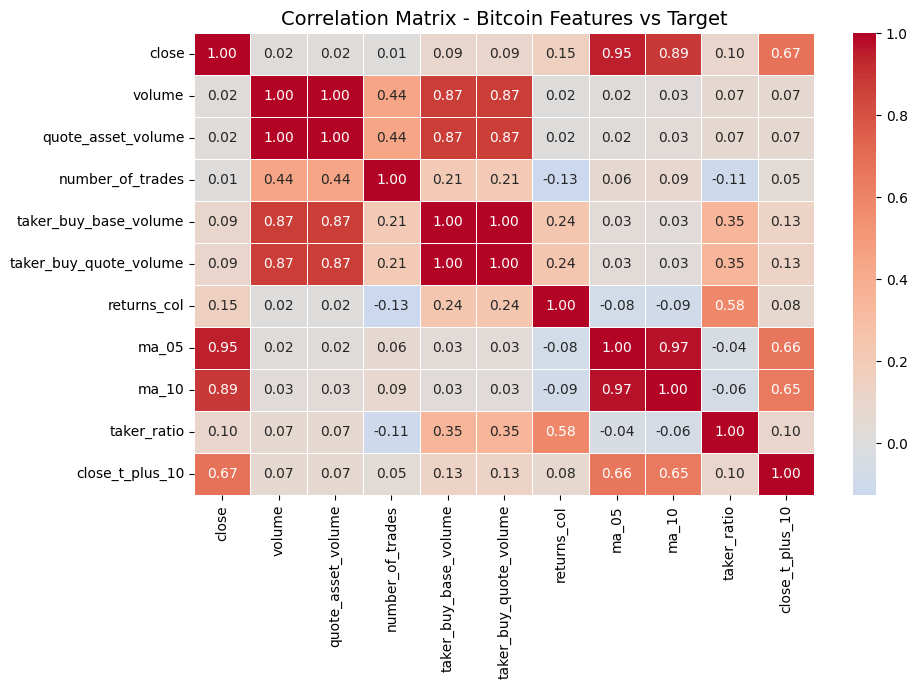

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_df,
    annot=True,       
    fmt=".2f",        
    cmap="coolwarm",   
    center=0,         
    linewidths=0.5
)

plt.title("Correlation Matrix - Bitcoin Features vs Target", fontsize=14)
plt.show()

In [58]:
df.write.parquet("data_silver.parquet")


print("Fichier Parquet sauvegardé ✅")

26/01/22 12:42:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/22 12:42:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/22 12:42:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/22 12:42:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/22 12:42:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Fichier Parquet sauvegardé ✅


In [59]:
df_sl = spark.read.parquet("data_silver.parquet")
df_sl.show()

+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+---------------+--------------------+-----------------+-----------------+-------------------+
|          open_time|    open|    high|     low|   close|  volume|          close_time|quote_asset_volume|number_of_trades|taker_buy_base_volume|taker_buy_quote_volume|ignore|close_t_plus_10|         returns_col|            ma_05|            ma_10|        taker_ratio|
+-------------------+--------+--------+--------+--------+--------+--------------------+------------------+----------------+---------------------+----------------------+------+---------------+--------------------+-----------------+-----------------+-------------------+
|2026-01-22 01:44:00|90010.14|90010.14|89992.83|89992.84| 1.78573|2026-01-22 01:44:...|    160709.3211419|             859|              0.83081|         74770.7942686|     0|       90145.88|-1